# Plot the calibrated observations
This includes radar attenuation rate and basal thermal evidence

In [97]:
%reload_ext autoreload
%autoreload 2
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append('../')
from src.plotting import Plotting
from src.utilities import load_ase_datasets

# load auxiliary data for plotting
aux_data = load_ase_datasets()
xs_ase, ys_ase = aux_data['coords']['xs'], aux_data['coords']['ys']
print("Keys of the auxiliary data dictionary:", aux_data.keys())

# creating plotting class
plotit = Plotting()
plotit.define_extent(xs_ase, ys_ase)
nx, ny = len(xs_ase), len(ys_ase)

  [load_ase_datasets] Loading reference coordinates …
  [load_ase_datasets] Loading Bedmap3 …
  [load_ase_datasets] Computing Tpmp …
  [load_ase_datasets] Computing surface slope …
  [load_ase_datasets] Loading velocity …
  [load_ase_datasets] Loading domain mask …
  [load_ase_datasets] All datasets ready.
Keys of the auxiliary data dictionary: dict_keys(['coords', 'sdem', 'bed', 'H', 'Tpmp', 'slope_x', 'slope_y', 'slope_mag', 'vx', 'vy', 'vel', 'mask', 'domain_bound_line'])


In [98]:
# path to the saved evidence data (these are calibrated and thinned from main.ipynb)
evidence_data_path = '../data/final-obs-evidence/'
atten_rate_name = 'atten_rate_calibrated.npz'
evidence_raw_name = "basal_thermal_classes.csv"

# load attenuation rate data
atten_rate_data = np.load(evidence_data_path + atten_rate_name)

# print the keys
print("Keys of the attenuation rate data: \n ", atten_rate_data.keys())

# load the basal evidence with detailed sources, but did not go through the thinning process
df = pd.read_csv(evidence_data_path + "/" + evidence_raw_name)
print(df["class_name"].value_counts())

# Split by class if needed
frozen       = df[df["class_name"] == "frozen"]
thawed_hicar = df[df["class_name"] == "thawed_hicar"]
thawed_pasin = df[df["class_name"] == "thawed_pasin"]
lakes        = df[df["class_name"] == "subglacial_lake"]


Keys of the attenuation rate data: 
  KeysView(NpzFile '../data/final-obs-evidence/atten_rate_calibrated.npz' with keys: atten_rate_calibrated, flight_mask, x, y)
class_name
thawed_hicar       2043
thawed_pasin       1404
frozen              900
subglacial_lake     259
Name: count, dtype: int64


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/plotting.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  # private: main + two stacked layout


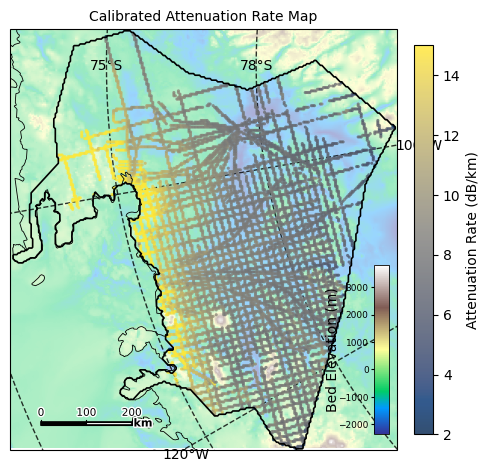

In [129]:
x = atten_rate_data['x']
y = atten_rate_data['y']
X, Y = np.meshgrid(x, y)
X = X.flatten()
Y = Y.flatten()

atten_rate_plot = atten_rate_data['atten_rate_calibrated'].reshape((ny, nx))
atten_rate_plot = np.where(atten_rate_data['flight_mask'], atten_rate_plot, np.nan)

atten_rate = dict(
    cb_label = 'Attenuation Rate (dB/km)',
    scalebar = (200, 2), # scale bar in km and number of segments
    title = 'Calibrated Attenuation Rate Map',
    layers = [
        dict(
            x = X,
            y = Y,
            data_type = 'scatter',
            data = atten_rate_plot,
            cmap = 'cividis',
            s = 5,
            alpha = 0.8,
            vmin = 2,
            vmax = 15,
        ),
        dict(
            x = aux_data['domain_bound_line'][0],
            y = aux_data['domain_bound_line'][1],
            data_type = 'line',
            color = 'k',
            linewidth = 1.2,
            alpha = 1.0
        ),
    ]
)
background = dict(
    x = xs_ase,
    y = ys_ase,
    data = aux_data['bed'],
    cmap = 'terrain',
    cb_label = 'Bed Elevation (m)',
    alpha = 0.4
)

plotit.define_extent(xs_ase, ys_ase)
fig = plotit.plot(data = (atten_rate,),
                  background= background)
fig.savefig('../figs/atten_rate_map.png', dpi=300, bbox_inches='tight')

In [108]:
x = evidence_data['x'].ravel()
y = evidence_data['y'].ravel()
ny, nx = len(y), len(x)
X, Y = np.meshgrid(x, y)
X = X.flatten()
Y = Y.flatten()

thawed_plot = evidence_data['new_thawed_mask'].reshape(nx, ny)
frozen_plot = evidence_data['new_frozen_mask'].reshape(nx, ny)

thawed_plot = np.where(thawed_plot==0, np.nan, 1)
frozen_plot = np.where(frozen_plot==0, np.nan, 1)

# only keep the non-nan values
x_thawed = X[~np.isnan(thawed_plot.flatten())]
y_thawed = Y[~np.isnan(thawed_plot.flatten())]
thawed_plot = thawed_plot[~np.isnan(thawed_plot)]

x_frozen = X[~np.isnan(frozen_plot.flatten())]
y_frozen = Y[~np.isnan(frozen_plot.flatten())]
frozen_plot = frozen_plot[~np.isnan(frozen_plot)]

/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/plotting.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  # private: main + two stacked layout


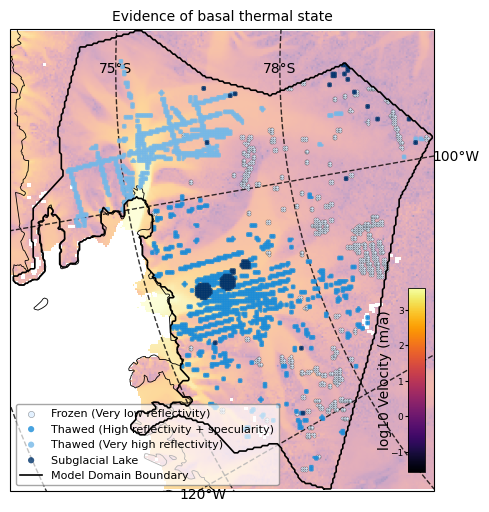

In [130]:
FROZEN_COLOR       = '#DDEEFF'   # icy pale blue-white
HICAR_COLOR        = '#1A8CD8'   # vivid cobalt   (high saturation)
PASIN_COLOR        = '#74B8E8'   # muted sky blue  (same hue, ~40% desaturated)
LAKE_COLOR         = '#00336B'   # deep navy       (highest confidence)

scatter_size  = 5
scatter_alpha = 0.8

thawed_frozen = dict(
    title    = 'Evidence of basal thermal state',
    colorbar = 'off',
    layers = [
        dict(
            data_type  = 'scatter',
            x          = frozen['x_m'],
            y          = frozen['y_m'],
            facecolors = FROZEN_COLOR,
            edgecolors = 'black',
            linewidths = 0.2,
            s          = scatter_size,
            alpha      = scatter_alpha,
            label      = 'Frozen (Very low reflectivity)'
        ),
        dict(
            data_type  = 'scatter',
            x          = thawed_hicar['x_m'],
            y          = thawed_hicar['y_m'],
            facecolors = HICAR_COLOR,
            edgecolors = 'none',
            linewidths = 0.3,
            s          = scatter_size,
            alpha      = scatter_alpha,
            label      = 'Thawed (High reflectivity + specularity)'
        ),
        dict(
            data_type  = 'scatter',
            x          = thawed_pasin['x_m'],
            y          = thawed_pasin['y_m'],
            facecolors = PASIN_COLOR,
            edgecolors = 'none',
            linewidths = 0.3,
            s          = scatter_size,
            alpha      = scatter_alpha,
            label      = 'Thawed (Very high reflectivity)'
        ),
        dict(
            data_type  = 'scatter',
            x          = lakes['x_m'],
            y          = lakes['y_m'],
            facecolors = LAKE_COLOR,
            edgecolors = 'none',
            linewidths = 0.3,
            s          = scatter_size,
            alpha      = scatter_alpha,
            label      = 'Subglacial Lake'
        ),
        # add the boundary line
        dict(
            data_type  = 'line',
            x          = aux_data['domain_bound_line'][0],
            y          = aux_data['domain_bound_line'][1],
            color      = 'k',
            linewidth  = 1.2,
            alpha      = 1.0,
            label      = 'Model Domain Boundary'
        )
    ]
)

background = dict(
    x = xs_ase,
    y = ys_ase,
    data = np.log10(aux_data['vel']),
    cmap = 'inferno',
    cb_label = 'log10 Velocity (m/a)',
    alpha = 0.4
)

plotit.define_extent(xs_ase, ys_ase)
fig = plotit.plot(data = (thawed_frozen,),
                  background= background)
fig.savefig('../figs/thawed_frozen_map.png', dpi=300, bbox_inches='tight')